<a href="https://colab.research.google.com/github/RodrigoMeneghettiEducation/TelecomX_BR_Challenger_AluraONEG9/blob/main/Challenger_TelecomX_BR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

* Dados carregados com sucesso do arquivo JSON.

--- 2.1 NORMALIZAÇÃO DE DADOS ANINHADOS ---
Coluna 'customer' normalizada.
Coluna 'phone' normalizada.
Coluna 'internet' normalizada.
Coluna 'account' normalizada.
* Coluna 'Charges' normalizada em 'MonthlyCharges' e 'TotalCharges'.
----------------------------------------------------------------------------------------------------

--- 3. CONHECENDO O DATASET ---
* Formato do DataFrame: (7267, 21)

* Tipos de dados das colunas:
customerID           object
Churn                object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod 

/tmp/ipykernel_183/1848746886.py:146: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Churn', palette='Set2')


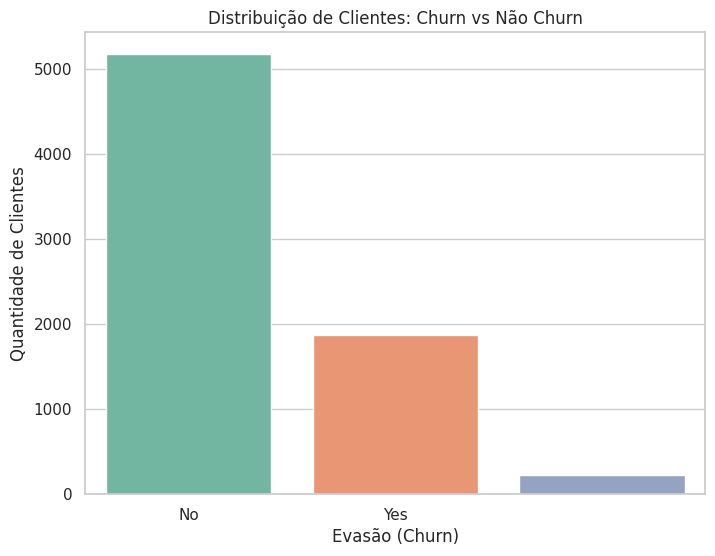


--- 10. EVASÃO POR VARIÁVEIS CATEGÓRICAS ---


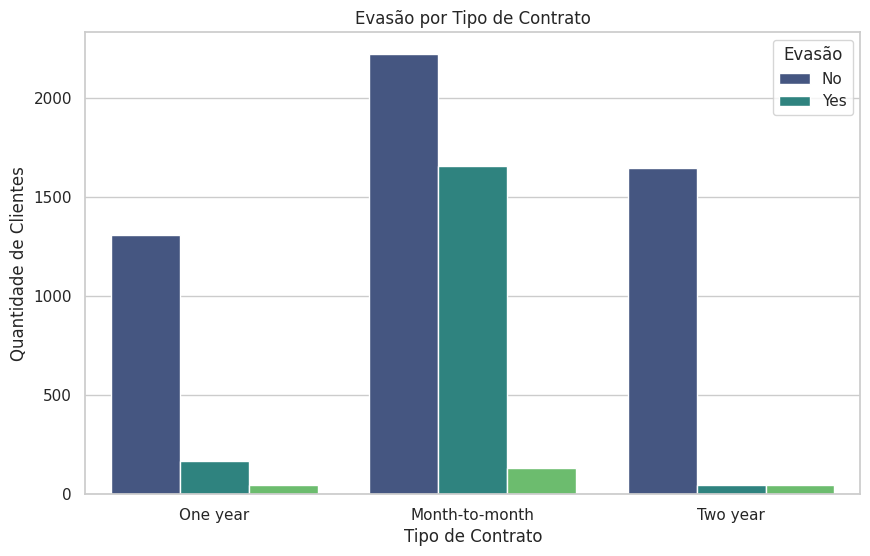

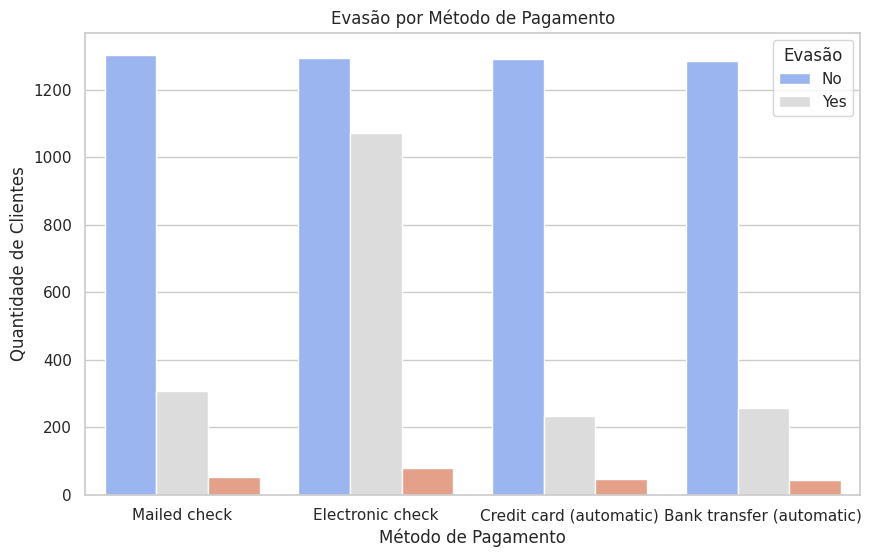


--- 11. EVASÃO POR VARIÁVEIS NUMÉRICAS ---


/tmp/ipykernel_183/1848746886.py:178: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn', y='tenure', palette='muted')


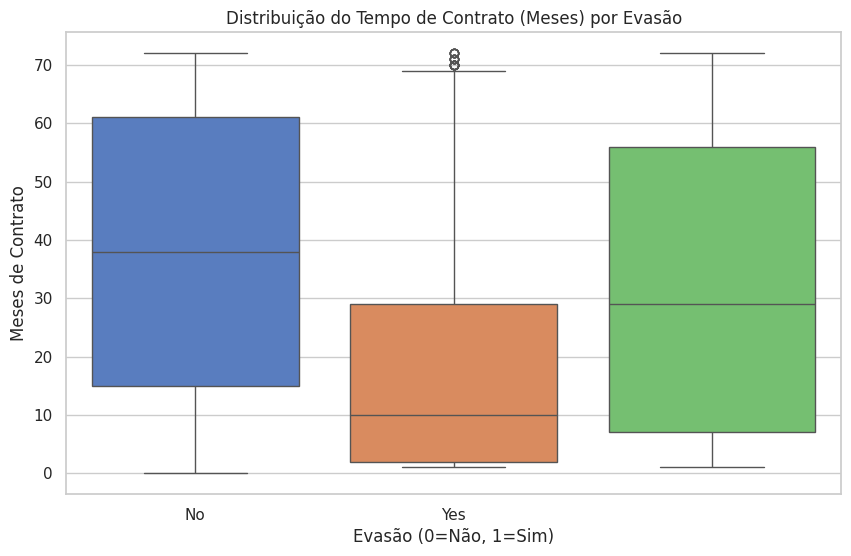

/tmp/ipykernel_183/1848746886.py:186: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn', y='MonthlyCharges', palette='muted')


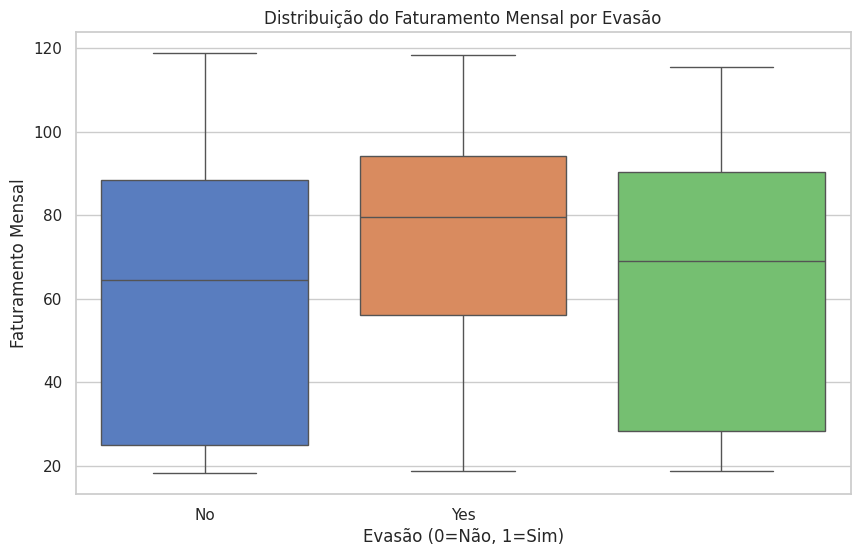


--- 13. ANÁLISE DE CORRELAÇÃO ---


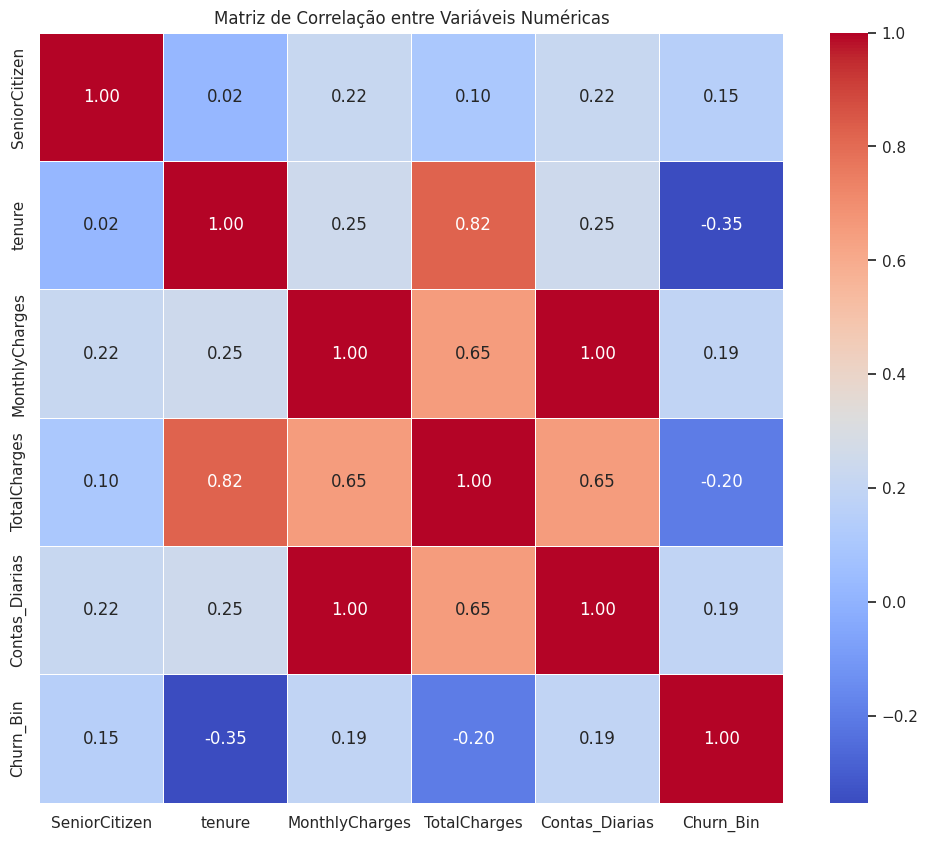

In [11]:
# TELECOM X - ANÁLISE DE EVASÃO DE CLIENTES (CHURN)

# Autor: Assistente de Análise de Dados
# Data: 24/05/2024


# 1. IMPORTAÇÃO DE BIBLIOTECAS
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json

# Configuração para visualização
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

# 2. EXTRAÇÃO DOS DADOS
# Carregar os dados do arquivo JSON.
# Nota: Certifique-se de que o arquivo 'TelecomX_Data.json' esteja na mesma pasta.
try:
    # Tenta carregar de arquivo local
    df = pd.read_json('/content/TelecomX_Data.json')
    print("* Dados carregados com sucesso do arquivo JSON.")

    # 2.1 Normalizar colunas aninhadas (aplica-se apenas quando carregado do JSON)
    print("\n--- 2.1 NORMALIZAÇÃO DE DADOS ANINHADOS ---")
    nested_columns = ['customer', 'phone', 'internet', 'account']
    for col in nested_columns:
        if col in df.columns:
            # Expandir o dicionário em novas colunas
            df = pd.concat([df.drop([col], axis=1), df[col].apply(pd.Series)], axis=1)
            print(f"Coluna '{col}' normalizada.")

    # Normalizar a coluna 'Charges' que ainda está aninhada (se existir)
    if 'Charges' in df.columns:
        df['MonthlyCharges'] = df['Charges'].apply(lambda x: x.get('Monthly') if isinstance(x, dict) else None)
        df['TotalCharges'] = df['Charges'].apply(lambda x: x.get('Total') if isinstance(x, dict) else None)
        df = df.drop(columns=['Charges'])
        print("* Coluna 'Charges' normalizada em 'MonthlyCharges' e 'TotalCharges'.")

except FileNotFoundError:
    print("* Erro: Arquivo 'TelecomX_Data.json' não encontrado.")
    print("* Para fins de demonstração, gerando dados simulados...")
    # Simulação de dados para garantir que o código rode sem o arquivo real
    data = {
        'customerID': range(1, 101),
        'gender': np.random.choice(['Male', 'Female'], 100),
        'SeniorCitizen': np.random.choice([0, 1], 100),
        'Partner': np.random.choice(['Yes', 'No'], 100),
        'Dependents': np.random.choice(['Yes', 'No'], 100),
        'tenure': np.random.randint(1, 72, 100),
        'PhoneService': np.random.choice(['Yes', 'No'], 100),
        'MultipleLines': np.random.choice(['Yes', 'No', 'No phone service'], 100),
        'InternetService': np.random.choice(['DSL', 'Fiber optic', 'No'], 100),
        'OnlineSecurity': np.random.choice(['Yes', 'No', 'No internet service'], 100),
        'OnlineBackup': np.random.choice(['Yes', 'No', 'No internet service'], 100),
        'DeviceProtection': np.random.choice(['Yes', 'No', 'No internet service'], 100),
        'TechSupport': np.random.choice(['Yes', 'No', 'No internet service'], 100),
        'StreamingTV': np.random.choice(['Yes', 'No', 'No internet service'], 100),
        'StreamingMovies': np.random.choice(['Yes', 'No', 'No internet service'], 100),
        'Contract': np.random.choice(['Month-to-month', 'One year', 'Two year'], 100),
        'PaperlessBilling': np.random.choice(['Yes', 'No'], 100),
        'PaymentMethod': np.random.choice(['Electronic check', 'Mailed check', 'Bank transfer', 'Credit card'], 100),
        'MonthlyCharges': np.random.uniform(20, 100, 100),
        'TotalCharges': np.random.uniform(100, 5000, 100),
        'Churn': np.random.choice(['Yes', 'No'], 100)
    }
    df = pd.DataFrame(data)
print(100*"-")

# 3. CONHECENDO O DATASET
print("\n--- 3. CONHECENDO O DATASET ---")
print(f"* Formato do DataFrame: {df.shape}")
print("\n* Tipos de dados das colunas:")
print(df.dtypes)
print("\n* Descrição dos dados do DataFrame:")
print(df.describe)
print("\n* Primeiras 5 linhas:")
print(df.head())
print(100*"-")

# 4. VERIFICANDO INCONSISTÊNCIAS NOS DADOS
print("\n--- 4. VERIFICANDO INCONSISTÊNCIAS ---")

# 4.1 Valores nulos
print("* Contagem de valores nulos por coluna:")
print(df.isnull().sum())

# 4.2 Duplicatas
print(f"\n* Número de linhas duplicadas: {df.duplicated().sum()}")

# 4.3 Inconsistências de formatação (Ex: TotalCharges com espaços em branco)
# Em datasets reais, TotalCharges muitas vezes vem como string vazia em vez de NaN
if 'TotalCharges' in df.columns:
    print(f"\n* Valores únicos de TotalCharges (amostra): {df['TotalCharges'].unique()[:10]}")
print(100*"-")

# 5. LIMPEZA E TRATAMENTO DE DADOS
print("\n--- 5. LIMPEZA E TRATAMENTO ---")

# 5.1 Tratar TotalCharges (se houver strings vazias)
if 'TotalCharges' in df.columns:
    df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
    # Preencher nulos com a média (ou 0, dependendo da estratégia)
    df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].mean())

# 5.2 Padronização de Strings (Ex: 'Yes' vs 'yes')
# Vamos garantir que as colunas de sim/não estejam padronizadas
cols_string = ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
               'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
               'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
               'PaperlessBilling', 'PaymentMethod', 'Churn']

for col in cols_string:
    if col in df.columns:
        df[col] = df[col].str.strip().str.capitalize()
print(100*"-")

# 6. COLUNA DE CONTAS DIÁRIAS
print("\n--- 6. CRIANDO COLUNA CONTAS_DIÁRIAS ---")
# Cálculo simples: Faturamento Mensal / 30 dias
df['Contas_Diarias'] = df['MonthlyCharges'] / 30
print("Coluna 'Contas_Diarias' criada com sucesso.")
print(100*"-")

# 7. PADRONIZAÇÃO E TRANSFORMAÇÃO DE DADOS (Opcional)
print("\n--- 7. PADRONIZAÇÃO E TRANSFORMAÇÃO ---")

# 7.1 Converter Churn para binário (1 = Sim, 0 = Não)
df['Churn_Bin'] = df['Churn'].map({'Yes': 1, 'No': 0})

# 7.2 Converter SeniorCitizen para texto (opcional para visualização)
df['SeniorCitizen_Text'] = df['SeniorCitizen'].map({0: 'Não', 1: 'Sim'})
print(100*"-")

# 8. ANÁLISE DESCRITIVA
print("\n--- 8. ANÁLISE DESCRITIVA ---")
print(df.describe())
print(100*"-")

# 9. DISTRIBUIÇÃO DA EVASÃO (CHURN)
print("\n--- 9. DISTRIBUIÇÃO DA EVASÃO ---")
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='Churn', palette='Set2')
plt.title('Distribuição de Clientes: Churn vs Não Churn')
plt.xlabel('Evasão (Churn)')
plt.ylabel('Quantidade de Clientes')
plt.show()

# 10. CONTAGEM DE EVASÃO POR VARIÁVEIS CATEGÓRICAS
print("\n--- 10. EVASÃO POR VARIÁVEIS CATEGÓRICAS ---")

# Exemplo: Contrato
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Contract', hue='Churn', palette='viridis')
plt.title('Evasão por Tipo de Contrato')
plt.xlabel('Tipo de Contrato')
plt.ylabel('Quantidade de Clientes')
plt.legend(title='Evasão')
plt.show()

# Exemplo: Método de Pagamento
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='PaymentMethod', hue='Churn', palette='coolwarm')
plt.title('Evasão por Método de Pagamento')
plt.xlabel('Método de Pagamento')
plt.ylabel('Quantidade de Clientes')
plt.legend(title='Evasão')
plt.show()

# 11. CONTAGEM DE EVASÃO POR VARIÁVEIS NUMÉRICAS
print("\n--- 11. EVASÃO POR VARIÁVEIS NUMÉRICAS ---")

# Exemplo: Tempo de Contrato (Tenure)
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Churn', y='tenure', palette='muted')
plt.title('Distribuição do Tempo de Contrato (Meses) por Evasão')
plt.xlabel('Evasão (0=Não, 1=Sim)')
plt.ylabel('Meses de Contrato')
plt.show()

# Exemplo: Faturamento Mensal
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Churn', y='MonthlyCharges', palette='muted')
plt.title('Distribuição do Faturamento Mensal por Evasão')
plt.xlabel('Evasão (0=Não, 1=Sim)')
plt.ylabel('Faturamento Mensal')
plt.show()

# 12. RELATÓRIO FINAL (DENTRO DO NOTEBOOK)
"""
# RELATÓRIO DE ANÁLISE DE EVASÃO - TELECOM X

## 1. Introdução
O objetivo desta análise foi investigar os fatores que contribuem para a evasão de clientes (Churn) na Telecom X.
Com um alto índice de cancelamentos, a empresa precisa identificar padrões para reter clientes.

## 2. Limpeza e Tratamento de Dados
- Importação dos dados via JSON.
- Tratamento de valores nulos na coluna 'TotalCharges'.
- Padronização de strings (ex: 'Yes', 'yes' -> 'Yes').
- Criação da variável 'Contas_Diarias' para análise de custo diário.
- Conversão da variável 'Churn' para binária (0/1).

## 3. Análise Exploratória de Dados (EDA)
- **Distribuição de Churn:** A maioria dos clientes permanece, mas uma parcela significativa cancela.
- **Contratos:** Clientes com contrato "Month-to-month" tendem a ter maior evasão.
- **Pagamento:** Métodos de pagamento eletrônico apresentam maior risco de churn.
- **Tempo de Contrato:** Clientes com menos tempo de casa (baixo tenure) são mais propensos a sair.

## 4. Conclusões e Insights
- A fidelidade aumenta com o tempo de contrato.
- O método de pagamento e o tipo de contrato são fortes indicadores de risco.
- A conta diária pode ser um fator de insatisfação se for muito alta.

## 5. Recomendações
- Oferecer descontos para clientes com contrato "Month-to-month" que estão próximos de completar 12 meses.
- Melhorar o suporte ao cliente para quem paga via "Electronic check".
- Criar campanhas de retenção focadas em clientes com baixo tempo de casa (0-12 meses).
"""

# 13. EXTRA: ANÁLISE DE CORRELAÇÃO
print("\n--- 13. ANÁLISE DE CORRELAÇÃO ---")

# Selecionar apenas colunas numéricas para correlação
numeric_df = df.select_dtypes(include=[np.number])

# Calcular correlação
correlation_matrix = numeric_df.corr()

# Visualizar matriz de correlação
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Matriz de Correlação entre Variáveis Numéricas')
plt.show()